<a href="https://colab.research.google.com/github/Basix77/project-delivery-delay-prediction-ML/blob/main/MLProject_delivery_delay_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Projekt: Przewidywanie opóźnień dostaw z wykorzystaniem uczenia maszynowego

## Autor
- Barbara Śmigielska

## Cel projektu

Celem projektu jest stworzenie modelu uczenia maszynowego przewidującego, czy dana dostawa będzie opóźniona. Wykorzystano dane logistyczne opisujące dostawy realizowane przez różnych partnerów logistycznych w Indiach.

Model może zostać wykorzystany do wcześniejszego wykrywania zagrożonych opóźnieniem dostaw oraz wspomagania planowania logistycznego.

In [ ]:
#import bibliotek i danych
 #dane
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import os
 #wykresy
import seaborn as sns
import matplotlib.pyplot as plt
 #modele
#from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np


path = kagglehub.dataset_download("muhammadahmaddaar/delivery-logistics-dataset-india-multi-partner")

df =  pd.read_csv(path + '/Delivery_Logistics.csv')

Using Colab cache for faster access to the 'delivery-logistics-dataset-india-multi-partner' dataset.


# Opis danych
| Nazwa kolumny       | Znaczenie                         |
| ------------------- | --------------------------------- |
| delivery_id         | identyfikator dostawy             |
| delivery_partner    | partner dostawy                   |
| package_type        | typ paczki                        |
| vehicle_type        | typ pojazdu                       |
| delivery_mode       | tryb dostawy                      |
| region              | region                            |
| weather_condition   | warunki pogodowe                  |
| distance_km         | dystans (km)                      |
| package_weight_kg   | waga paczki (kg)                  |
| delivery_time_hours | czas dostawy (w godzinach)            |
| expected_time_hours | oczekiwany czas dostawy (w godzinach) |
| delayed             | opóźnienie (tak/nie)              |
| delivery_status     | status dostawy                    |
| delivery_rating     | ocena dostawy                     |
| delivery_cost       | koszt dostawy                     |


In [ ]:
#sprawdzenie brakujących danych
df.isnull().sum()

,0
delivery_id,0
delivery_partner,0
package_type,0
vehicle_type,0
delivery_mode,0
region,0
weather_condition,0
distance_km,0
package_weight_kg,0
delivery_time_hours,0


In [ ]:
#czyszczenie - id dostawy nie jest nam potrzebne do analizy
df = df.drop('delivery_id', axis=1)

In [ ]:
df.head()

,delivery_partner,package_type,vehicle_type,delivery_mode,region,weather_condition,distance_km,package_weight_kg,delivery_time_hours,expected_time_hours,delayed,delivery_status,delivery_rating,delivery_cost
0,delhivery,automobile parts,bike,same day,west,clear,297.0,46.96,1970-01-01 00:00:00.000000008,1970-01-01 00:00:00.000000008,no,delivered,3,1632.7206
1,xpressbees,cosmetics,ev van,express,central,cold,89.6,47.39,1970-01-01 00:00:00.000000002,1970-01-01 00:00:00.000000003,no,delivered,5,640.1700
2,shadowfax,groceries,truck,two day,east,rainy,273.5,26.89,1970-01-01 00:00:00.000000010,1970-01-01 00:00:00.000000016,no,delivered,4,1448.1700
3,dhl,electronics,ev van,same day,east,cold,269.7,12.69,1970-01-01 00:00:00.000000006,1970-01-01 00:00:00.000000008,no,delivered,3,1486.5700
4,dhl,clothing,van,two day,north,foggy,256.7,37.02,1970-01-01 00:00:00.000000009,1970-01-01 00:00:00.000000016,no,delivered,4,1394.5600


In [ ]:
#zamiana jednostek w aktualnym i oczekiwanym czasie dostawy

def extract_hours_from_str(time_str):
    fractional = time_str.split('.')[-1]
    return int(fractional)

df['actual_delivery_hours'] = df['delivery_time_hours'].apply(extract_hours_from_str)
df['expected_delivery_hours'] = df['expected_time_hours'].apply(extract_hours_from_str)

df.drop(['delivery_time_hours', 'expected_time_hours'], axis=1, inplace=True)


In [ ]:
df.head()

,delivery_partner,package_type,vehicle_type,delivery_mode,region,weather_condition,distance_km,package_weight_kg,delayed,delivery_status,delivery_rating,delivery_cost,actual_delivery_hours,expected_delivery_hours
0,delhivery,automobile parts,bike,same day,west,clear,297.0,46.96,no,delivered,3,1632.7206,8,8
1,xpressbees,cosmetics,ev van,express,central,cold,89.6,47.39,no,delivered,5,640.1700,2,3
2,shadowfax,groceries,truck,two day,east,rainy,273.5,26.89,no,delivered,4,1448.1700,10,16
3,dhl,electronics,ev van,same day,east,cold,269.7,12.69,no,delivered,3,1486.5700,6,8
4,dhl,clothing,van,two day,north,foggy,256.7,37.02,no,delivered,4,1394.5600,9,16


In [ ]:
#zamiana, aby model rozumiał jako liczby dane, które są tekstowe
df_encoded = pd.get_dummies(
    df,
    columns=[
        "delivery_partner",
        "package_type",
        "vehicle_type",
        "delivery_mode",
        "region",
        "weather_condition",
        "delivery_status"
    ],
    drop_first=True
)

In [ ]:
#podział na dane czyste i werdykt
x = df_encoded.drop("delayed", axis=1)
y = df_encoded["delayed"]


In [ ]:
#podział na dane treningowe i testowe
x_train, x_test, y_train, y_test = train_test_split(x, y, train_size=0.8, random_state=42)

In [ ]:
# Inicjalizacja modelu Drzewa Decyzyjnego
tree_model = DecisionTreeClassifier(max_depth=4, random_state=42)
# Trening modelu
tree_model.fit(x_train, y_train)
#testowanie skutecznosci modelu
tree_predict = tree_model.predict(x_test)
# Raport skuteczności
print("Raport dla Drzewa Decyzyjnego:")
print(classification_report(y_test, tree_predict))


Raport dla Drzewa Decyzyjnego:
              precision    recall  f1-score   support

          no       1.00      1.00      1.00      3677
         yes       1.00      1.00      1.00      1323

    accuracy                           1.00      5000
   macro avg       1.00      1.00      1.00      5000
weighted avg       1.00      1.00      1.00      5000



In [ ]:
#KNN
#inicjalizacja model
knn_model = KNeighborsClassifier(n_neighbors=3)
#trening modelu
knn_model.fit(x_train, y_train)
#testowanie skutecznosci modelu
knn_predict = knn_model.predict(x_test)
# Raport skuteczności
print("Raport dla KNN:")
print(classification_report(y_test, knn_predict))

Raport dla KNN:
              precision    recall  f1-score   support

          no       0.95      0.93      0.94      3677
         yes       0.82      0.86      0.84      1323

    accuracy                           0.91      5000
   macro avg       0.88      0.90      0.89      5000
weighted avg       0.92      0.91      0.91      5000



In [ ]:
# skalowanie danych i trenowanie modelu na skalowanych danych
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)
x_train_scaled, x_test_scaled, y_train, y_test = train_test_split(x_scaled,y,train_size=0.7)

In [ ]:
# Inicjalizacja modelu KNN dla danych skalowanych
knn_scaled_model = KNeighborsClassifier(n_neighbors=3)

# Trening na danych skalowanych
knn_scaled_model.fit(x_train_scaled, y_train)

# Predykcja
knn_scaled_predict = knn_scaled_model.predict(x_test_scaled)

In [ ]:
# Raport skuteczności
print("Raport dla KNN na danych skalowalnych:")
print(classification_report(y_test, knn_scaled_predict))

Raport dla KNN na danych skalowalnych:
              precision    recall  f1-score   support

          no       0.98      0.99      0.99      5487
         yes       0.98      0.95      0.97      2013

    accuracy                           0.98      7500
   macro avg       0.98      0.97      0.98      7500
weighted avg       0.98      0.98      0.98      7500



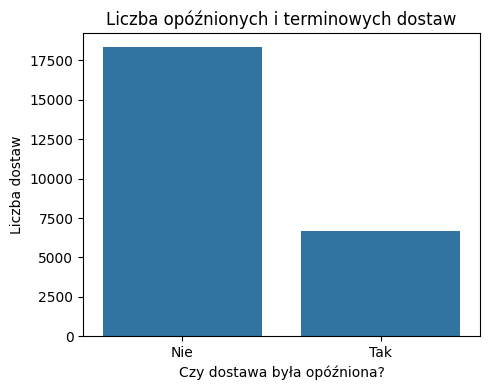

In [ ]:
plt.figure(figsize=(5,4))
sns.countplot(data=df, x="delayed")

plt.title("Liczba opóźnionych i terminowych dostaw")
plt.xlabel("Czy dostawa była opóźniona?")
plt.ylabel("Liczba dostaw")

plt.xticks([0, 1], ["Nie", "Tak"])

plt.tight_layout()
plt.show()

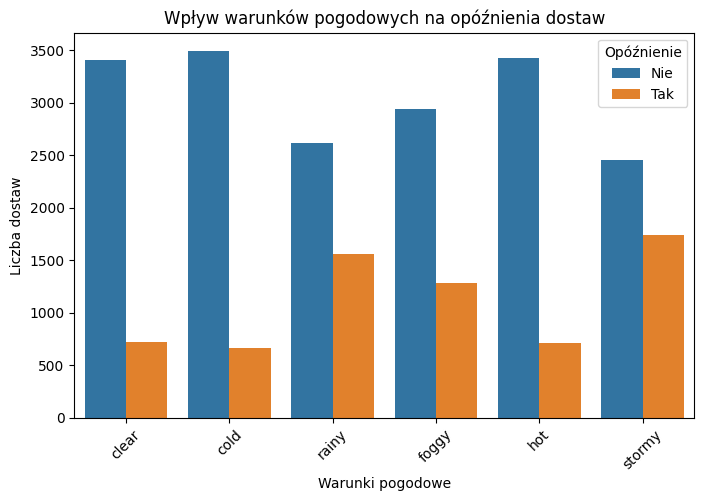

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="weather_condition", hue="delayed")
plt.title("Wpływ warunków pogodowych na opóźnienia dostaw")
plt.xlabel("Warunki pogodowe")
plt.ylabel("Liczba dostaw")
plt.legend(title="Opóźnienie", labels=["Nie", "Tak"])
plt.xticks(rotation=45)
plt.show()

In [ ]:
#Tworzenie nowych danych, aby sprawdzić czy model przewidzi opóźnienie
new_delivery = x.iloc[[0]].copy()



new_delivery["distance_km"] = 240
new_delivery["package_weight_kg"] = 8
new_delivery["delivery_cost"] = 150
new_delivery["expected_delivery_hours"] = 5

new_scaled = scaler.transform(new_delivery)

# Prawdopodobieństwo opóźnienia - KNN
prediction = knn_scaled_model.predict_proba(new_scaled)
probabilities = knn_scaled_model.predict_proba(new_scaled)
prob_delayed = probabilities[0][1] * 100

print("Model KNN - Czy dostawa będzie opóźniona?")
print(f"Prawdopodobieństwo opóźnienia dostawy wynosi: {prob_delayed:.2f}%")


Model KNN - Czy dostawa będzie opóźniona?
Prawdopodobieństwo opóźnienia dostawy wynosi: 33.33%


In [ ]:
# Prawdopodobieństwo decision tree

tree_prediction = tree_model.predict(new_delivery)
tree_probabilities = tree_model.predict_proba(new_delivery)
prob_delayed_tree = tree_probabilities[0][1] * 100

print("Drzewo Decyzyjne - Czy dostawa będzie opóźniona?")
print(f"Prawdopodobieństwo opóźnienia wynosi: {prob_delayed_tree:.2f}%")

Drzewo Decyzyjne - Czy dostawa będzie opóźniona?
Prawdopodobieństwo opóźnienia wynosi: 0.00%


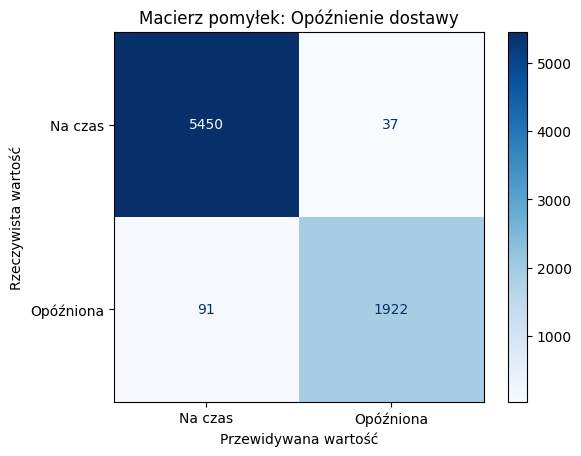

In [ ]:
# Macierz pomyłek
cm = confusion_matrix(y_test, knn_scaled_predict)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap=plt.cm.Blues)

plt.title("Macierz pomyłek: Opóźnienie dostawy")
plt.xlabel("Przewidywana wartość")
plt.ylabel("Rzeczywista wartość")
labels = ["Na czas", "Opóźniona"]
plt.show()